<a href="https://colab.research.google.com/github/mmuputisi/Adv-Py_Data_Analysis/blob/main/ESG%20non-linear%20match%20original.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

NON-LINEAR EFFECTS ANALYSIS - EXACT MATCH TO ORIGINAL

1. RUNNING EXACT QUADRATIC MODEL (Consumer Staples)

NON-LINEAR (QUADRATIC) MODEL - EXACT MATCH TO ORIGINAL
Loading data exactly as in original analysis...
✓ Loaded 388 total observations
✓ Consumer Staples: 80 observations
✓ Created quadratic terms: E_lag_sq, S_lag_sq, G_lag_sq

Model Specification (exact match to original):
  Sector: Consumer Staples Only
  Dependent: Tobin_Q
  ESG variables: ['E_lag', 'E_lag_sq', 'S_lag', 'S_lag_sq', 'G_lag', 'G_lag_sq']
  Control variables: ['ROA', 'Size', 'Leverage']
  Fixed effects: None (pooled OLS)
  SE: Robust (HC1)

Data Summary:
  Total observations: 80
  Observations after cleaning: 72
  Firms: 8
  Years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Variable Summary Statistics:
  E_lag: mean=80.2171, sd=13.7378
  E_lag_sq: mean=6620.8877, sd=1898.5

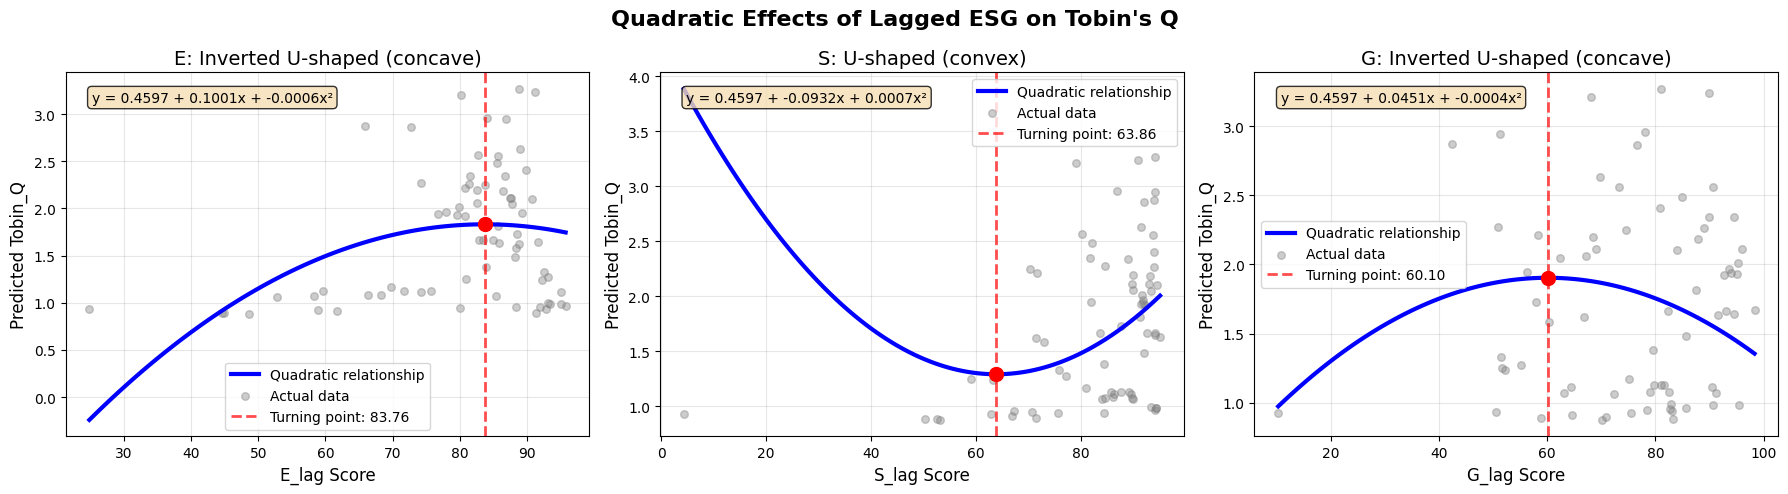


2. RUNNING DIAGNOSTIC

DIAGNOSTIC: IDENTIFYING DIFFERENCES FROM ORIGINAL
Original reported R²: 0.571700
Loading data exactly as in original analysis...
✓ Loaded 388 total observations
✓ Consumer Staples: 80 observations
✓ Created quadratic terms: E_lag_sq, S_lag_sq, G_lag_sq

1. CHECKING VARIABLE CREATION:
----------------------------------------
  ✓ E_lag: 72/80 non-missing
  ✓ E_lag_sq: 72/80 non-missing
  ✓ S_lag: 72/80 non-missing
  ✓ S_lag_sq: 72/80 non-missing
  ✓ G_lag: 72/80 non-missing
  ✓ G_lag_sq: 72/80 non-missing
  ✓ ROA: 80/80 non-missing
  ✓ Size: 80/80 non-missing
  ✓ Leverage: 80/80 non-missing
  ✓ Tobin_Q: 80/80 non-missing

2. CHECKING DATA RANGES:
----------------------------------------
  E_lag: min=24.8300, max=95.7900, mean=80.2171, sd=13.7378
  S_lag: min=4.2700, max=95.1400, mean=82.9769, sd=14.6886
  G_lag: min=10.3300, max=98.3200, mean=75.8010, sd=16.2610
  Tobin_Q: min=0.8773, max=3.4606, mean=1.7662, sd=0.7234

3. CHECKING QUADRATIC TERMS:
---------------

In [2]:
# standalone_nonlinear_corrected.py
"""
Non-Linear Effects Model - Corrected to match original structured analysis
"""

# ============================================================================
# SETUP AND IMPORTS
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install -q linearmodels pandas numpy matplotlib seaborn statsmodels

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Configuration matching original structured analysis"""
    PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/FTSE Data'
    DATA_PATH = os.path.join(PROJECT_DIR, 'FTSE data.xlsx')
    OUTPUT_DIR = os.path.join(PROJECT_DIR, 'nonlinear_corrected_outputs')

    # Consumer Staples firms (must match original)
    CONSUMER_STAPLES_FIRMS = [
        'Associated British Foods', 'British American Tobacco', 'Coca Cola HBC AG',
        'Diageo', 'J. Sainsbury', 'Reckitt Benckiser', 'Tesco', 'Unilever', 'Haleon Plc'
    ]

# ============================================================================
# DATA LOADER - EXACT MATCH TO ORIGINAL
# ============================================================================
class DataLoader:
    """Load data exactly as in original structured analysis"""

    def __init__(self, config):
        self.config = config
        self.df = None
        self.df_cs = None

    def load_and_prepare_exact(self):
        """
        Load data EXACTLY as in original structured analysis
        This matches the code before the non-linear transformations
        """
        print("Loading data exactly as in original analysis...")

        # 1. Load Excel file
        self.df = pd.read_excel(self.config.DATA_PATH)

        # 2. Set index exactly as original
        self.df = self.df.set_index(['Firm', 'Year']).sort_index()

        # 3. Rename Tobin's Q exactly as original
        self.df = self.df.rename(columns={"Tobin's Q": "Tobin_Q"})

        # 4. Create transformed variables exactly as original
        self.df['Size'] = np.log(self.df['Total Assets'])
        self.df['Leverage'] = self.df['Total Liabilities'] / self.df['Total Assets']
        self.df['Tobin_Q_log'] = np.log(self.df['Tobin_Q'] + 0.001)

        # 5. Create lagged ESG variables exactly as original
        self.df['E_lag'] = self.df.groupby(level=0)['E'].shift(1)
        self.df['S_lag'] = self.df.groupby(level=0)['S'].shift(1)
        self.df['G_lag'] = self.df.groupby(level=0)['G'].shift(1)

        # 6. Create lagged control variables exactly as original
        self.df['ROA_lag'] = self.df.groupby(level=0)['ROA'].shift(1)
        self.df['Size_lag'] = self.df.groupby(level=0)['Size'].shift(1)
        self.df['Leverage_lag'] = self.df.groupby(level=0)['Leverage'].shift(1)

        # 7. Create sector variable exactly as original
        sectors = []
        for firm in self.df.index.get_level_values(0):
            if firm in self.config.CONSUMER_STAPLES_FIRMS:
                sectors.append('Consumer Staples')
            else:
                sectors.append('Other')

        self.df['Sector'] = sectors
        self.df['ConsumerStaples'] = (self.df['Sector'] == 'Consumer Staples').astype(int)

        # 8. Create Consumer Staples dataset exactly as original
        self.df_cs = self.df[self.df['ConsumerStaples'] == 1].copy()

        # 9. Create 2-year and 3-year moving averages exactly as original
        for component in ['E_lag', 'S_lag', 'G_lag']:
            # 2-year MA
            self.df_cs[f'{component}_ma2'] = self.df_cs.groupby(level=0)[component].rolling(
                window=2, min_periods=2).mean().reset_index(level=0, drop=True)
            # 3-year MA
            self.df_cs[f'{component}_ma3'] = self.df_cs.groupby(level=0)[component].rolling(
                window=3, min_periods=3).mean().reset_index(level=0, drop=True)

        # 10. Create additional transformations exactly as original
        for component in ['E_lag', 'S_lag', 'G_lag']:
            # Quadratic terms (THIS IS WHAT WE NEED FOR NON-LINEAR MODEL)
            self.df_cs[f'{component}_sq'] = self.df_cs[component] ** 2

        print(f"✓ Loaded {len(self.df)} total observations")
        print(f"✓ Consumer Staples: {len(self.df_cs)} observations")
        print(f"✓ Created quadratic terms: E_lag_sq, S_lag_sq, G_lag_sq")

        return self.df, self.df_cs

# ============================================================================
# NON-LINEAR MODEL ANALYZER - EXACT MATCH
# ============================================================================
class NonlinearAnalyzerExact:
    """Analyzer that EXACTLY matches original non-linear model"""

    def __init__(self, config):
        self.config = config
        self.loader = DataLoader(config)
        self.results = {}

    def run_nonlinear_model_exact(self, sector='cs', y_var='Tobin_Q'):
        """
        Run the exact non-linear model from original structured analysis

        Original Model 6 specification:
        esg_vars: ['E_lag', 'E_lag_sq', 'S_lag', 'S_lag_sq', 'G_lag', 'G_lag_sq']
        control_vars: ['ROA', 'Size', 'Leverage']
        """
        print("\n" + "="*80)
        print("NON-LINEAR (QUADRATIC) MODEL - EXACT MATCH TO ORIGINAL")
        print("="*80)

        # Load data exactly as original
        df, df_cs = self.loader.load_and_prepare_exact()

        # Select dataset based on sector
        if sector == 'cs':
            analysis_df = df_cs.copy()
            sector_name = 'Consumer Staples Only'
            control_vars = ['ROA', 'Size', 'Leverage']  # Original uses CURRENT controls
            add_sector_dummy = False
        else:
            analysis_df = df.copy()
            sector_name = 'All Sectors'
            control_vars = ['ROA', 'Size', 'Leverage', 'ConsumerStaples']
            add_sector_dummy = True

        # EXACT VARIABLES FROM ORIGINAL MODEL 6
        esg_vars = ['E_lag', 'E_lag_sq', 'S_lag', 'S_lag_sq', 'G_lag', 'G_lag_sq']

        print(f"\nModel Specification (exact match to original):")
        print(f"  Sector: {sector_name}")
        print(f"  Dependent: {y_var}")
        print(f"  ESG variables: {esg_vars}")
        print(f"  Control variables: {control_vars}")
        print(f"  Fixed effects: None (pooled OLS)")
        print(f"  SE: Robust (HC1)")

        # Check if all variables exist
        all_vars = esg_vars + control_vars + [y_var]
        missing_vars = [v for v in all_vars if v not in analysis_df.columns]

        if missing_vars:
            print(f"\n⚠ Missing variables: {missing_vars}")
            print("Creating missing variables...")

            # Create missing quadratic terms
            for var in ['E_lag_sq', 'S_lag_sq', 'G_lag_sq']:
                if var not in analysis_df.columns and var.replace('_sq', '') in analysis_df.columns:
                    analysis_df[var] = analysis_df[var.replace('_sq', '')] ** 2
                    print(f"  Created {var}")

            # Re-check
            missing_vars = [v for v in all_vars if v not in analysis_df.columns]
            if missing_vars:
                print(f"  Still missing: {missing_vars}")
                return None

        # Clean data (drop NAs for all variables)
        df_clean = analysis_df.dropna(subset=all_vars)

        if len(df_clean) < 10:
            print(f"⚠ Insufficient data: {len(df_clean)} observations")
            return None

        print(f"\nData Summary:")
        print(f"  Total observations: {len(analysis_df)}")
        print(f"  Observations after cleaning: {len(df_clean)}")
        print(f"  Firms: {df_clean.index.get_level_values(0).nunique()}")
        print(f"  Years: {sorted(df_clean.index.get_level_values(1).unique())}")

        # Summary statistics for key variables
        print(f"\nVariable Summary Statistics:")
        for var in esg_vars[:3]:  # Just linear terms
            if var in df_clean.columns:
                print(f"  {var}: mean={df_clean[var].mean():.4f}, sd={df_clean[var].std():.4f}")

        # Run regression EXACTLY as original
        print(f"\nRunning regression...")

        y = df_clean[y_var]
        X = df_clean[esg_vars + control_vars]
        X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

        try:
            # Use PanelOLS with no fixed effects (pooled OLS)
            model = PanelOLS(y, X, entity_effects=False, time_effects=False)
            results = model.fit(cov_type='robust')  # Original uses robust SE

            # Store results
            key = f"nonlinear_quadratic_{sector}_{y_var}"
            self.results[key] = {
                'results': results,
                'type': 'quadratic',
                'sector': sector,
                'y_var': y_var,
                'nobs': results.nobs,
                'r2': results.rsquared,
                'r2_adj': results.rsquared_adj if hasattr(results, 'rsquared_adj') else results.rsquared,
                'data': df_clean
            }

            # Print detailed results
            self._print_detailed_results_exact(results, y_var, esg_vars, control_vars)

            # Calculate and display turning points
            self._calculate_turning_points_exact(results, df_clean)

            # Plot quadratic effects
            self._plot_quadratic_effects_exact(df_clean, results, y_var)

            return results

        except Exception as e:
            print(f"✗ Error running regression: {e}")
            import traceback
            traceback.print_exc()
            return None

    def _print_detailed_results_exact(self, results, y_var, esg_vars, control_vars):
        """Print detailed results exactly as original would"""
        print("\n" + "="*80)
        print("REGRESSION RESULTS - NON-LINEAR (QUADRATIC) MODEL")
        print("="*80)

        print(f"\nModel Statistics:")
        print(f"  R-squared: {results.rsquared:.6f}")
        print(f"  Adjusted R-squared: {results.rsquared_adj:.6f}" if hasattr(results, 'rsquared_adj') else f"  Adjusted R-squared: {results.rsquared:.6f}")
        print(f"  Observations: {results.nobs}")

        if hasattr(results, 'f_statistic'):
            print(f"  F-statistic: {results.f_statistic.stat:.4f} (p={results.f_statistic.pval:.4f})")

        # Construct equation
        print(f"\nRegression Equation:")
        equation = self._construct_equation_exact(results, y_var, esg_vars, control_vars)
        print(equation)

        # Print coefficient table
        print(f"\nCoefficient Estimates:")
        print("-" * 70)
        print(f"{'Variable':<20} {'Coefficient':>12} {'Std. Error':>12} {'t-stat':>10} {'p-value':>10} {'Sig.':>6}")
        print("-" * 70)

        for var in results.params.index:
            if var != 'const':
                coeff = results.params[var]
                se = results.std_errors.get(var, np.nan)
                t_stat = coeff / se if se != 0 and not np.isnan(se) else np.nan
                pval = results.pvalues.get(var, np.nan)
                sig = self._get_significance_stars(pval)

                print(f"{var:<20} {coeff:>12.6f} {se:>12.6f} {t_stat:>10.4f} {pval:>10.4f} {sig:>6}")

        # Constant
        if 'const' in results.params:
            coeff = results.params['const']
            se = results.std_errors.get('const', np.nan)
            t_stat = coeff / se if se != 0 and not np.isnan(se) else np.nan
            pval = results.pvalues.get('const', np.nan)
            sig = self._get_significance_stars(pval)

            print(f"{'const':<20} {coeff:>12.6f} {se:>12.6f} {t_stat:>10.4f} {pval:>10.4f} {sig:>6}")

    def _construct_equation_exact(self, results, y_var, esg_vars, control_vars):
        """Construct regression equation exactly as in original"""
        equation_parts = [f"{y_var}(t) = "]

        # Add constant
        if 'const' in results.params:
            const = results.params['const']
            if const >= 0:
                equation_parts.append(f"{const:.6f}")
            else:
                equation_parts.append(f"- {abs(const):.6f}")

        # Add ESG variables (grouped by component)
        esg_components = {}
        for var in esg_vars:
            for component in ['E', 'S', 'G']:
                if component in var:
                    if component not in esg_components:
                        esg_components[component] = []
                    esg_components[component].append(var)

        for component, vars_list in esg_components.items():
            vars_list = sorted(vars_list)  # Linear first, then quadratic

            for var in vars_list:
                if var in results.params:
                    coeff = results.params[var]
                    pval = results.pvalues.get(var, 1.0)
                    sig = self._get_significance_stars(pval)

                    # Format variable name
                    if '_sq' in var:
                        base_var = var.replace('_sq', '')
                        display_var = f"({base_var})²"
                    else:
                        display_var = var

                    if coeff >= 0:
                        equation_parts.append(f"+ {coeff:.6f}{sig}·{display_var}")
                    else:
                        equation_parts.append(f"- {abs(coeff):.6f}{sig}·{display_var}")

        # Add control variables
        for var in control_vars:
            if var in results.params:
                coeff = results.params[var]
                pval = results.pvalues.get(var, 1.0)
                sig = self._get_significance_stars(pval)

                if coeff >= 0:
                    equation_parts.append(f"+ {coeff:.6f}{sig}·{var}")
                else:
                    equation_parts.append(f"- {abs(coeff):.6f}{sig}·{var}")

        equation = " ".join(equation_parts) + " + ε"
        return equation

    def _calculate_turning_points_exact(self, results, df_clean):
        """Calculate turning points for quadratic relationships"""
        print(f"\n" + "-"*60)
        print("QUADRATIC EFFECTS ANALYSIS")
        print("-"*60)

        turning_points = {}

        for component in ['E', 'S', 'G']:
            linear_var = f'{component}_lag'
            quad_var = f'{component}_lag_sq'

            if linear_var in results.params and quad_var in results.params:
                beta1 = results.params[linear_var]
                beta2 = results.params[quad_var]
                p1 = results.pvalues.get(linear_var, 1.0)
                p2 = results.pvalues.get(quad_var, 1.0)

                # Only calculate if quadratic term is significant
                if p2 < 0.10:
                    if beta2 != 0:
                        turning_point = -beta1 / (2 * beta2)

                        # Check if turning point is within data range
                        data_min = df_clean[linear_var].min()
                        data_max = df_clean[linear_var].max()

                        within_range = data_min <= turning_point <= data_max

                        shape = "U-shaped (minimum)" if beta2 > 0 else "Inverted U-shaped (maximum)"

                        turning_points[component] = {
                            'turning_point': turning_point,
                            'shape': shape,
                            'beta1': beta1,
                            'beta2': beta2,
                            'p1': p1,
                            'p2': p2,
                            'within_range': within_range,
                            'data_min': data_min,
                            'data_max': data_max
                        }

        if turning_points:
            print(f"\nSignificant Quadratic Effects (Turning Points):")
            for component, info in turning_points.items():
                print(f"\n  {component} component:")
                print(f"    Shape: {info['shape']}")
                print(f"    Turning point: {info['turning_point']:.6f}")
                print(f"    Within data range [{info['data_min']:.2f}, {info['data_max']:.2f}]: {'Yes' if info['within_range'] else 'No'}")
                print(f"    Linear coefficient (β₁): {info['beta1']:.6f} (p={info['p1']:.4f})")
                print(f"    Quadratic coefficient (β₂): {info['beta2']:.6f} (p={info['p2']:.4f})")

                # Calculate marginal effect at mean
                mean_x = df_clean[f'{component}_lag'].mean()
                marginal_effect = info['beta1'] + 2 * info['beta2'] * mean_x
                print(f"    Marginal effect at mean ({mean_x:.2f}): {marginal_effect:.6f}")
        else:
            print(f"\nNo significant quadratic effects found.")

        return turning_points

    def _plot_quadratic_effects_exact(self, df_clean, results, y_var):
        """Plot quadratic effects exactly as needed"""
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Quadratic Effects of Lagged ESG on Tobin\'s Q',
                    fontsize=16, fontweight='bold')

        for idx, component in enumerate(['E', 'S', 'G']):
            linear_var = f'{component}_lag'
            quad_var = f'{component}_lag_sq'

            if linear_var in results.params and quad_var in results.params:
                # Extract coefficients
                beta0 = results.params['const']
                beta1 = results.params[linear_var]
                beta2 = results.params[quad_var]

                # Calculate control variable effects at their means
                control_effect = 0
                for var in df_clean.columns:
                    if var in results.params and var not in ['const', linear_var, quad_var]:
                        if var in df_clean.columns:
                            control_mean = df_clean[var].mean()
                            control_effect += results.params[var] * control_mean

                # Generate predicted values
                x_min = df_clean[linear_var].min()
                x_max = df_clean[linear_var].max()
                x_range = np.linspace(x_min, x_max, 100)

                # Calculate predicted y
                y_pred = beta0 + beta1 * x_range + beta2 * (x_range ** 2) + control_effect

                # Calculate turning point if quadratic is significant
                turning_point = None
                if beta2 != 0:
                    turning_point = -beta1 / (2 * beta2)

                # Plot
                axes[idx].plot(x_range, y_pred, 'b-', linewidth=3,
                              label='Quadratic relationship')

                # Add scatter of actual data
                axes[idx].scatter(df_clean[linear_var], df_clean[y_var],
                                 alpha=0.4, s=30, color='gray',
                                 label='Actual data')

                # Add turning point line if within range
                if turning_point and x_min <= turning_point <= x_max:
                    # Find y at turning point
                    y_turning = beta0 + beta1 * turning_point + beta2 * (turning_point ** 2) + control_effect
                    axes[idx].axvline(x=turning_point, color='red', linestyle='--',
                                     linewidth=2, alpha=0.7,
                                     label=f'Turning point: {turning_point:.2f}')
                    axes[idx].plot(turning_point, y_turning, 'ro', markersize=10)

                axes[idx].set_xlabel(f'{component}_lag Score', fontsize=12)
                axes[idx].set_ylabel(f'Predicted {y_var}', fontsize=12)

                # Determine shape
                if beta2 > 0:
                    shape = "U-shaped (convex)"
                elif beta2 < 0:
                    shape = "Inverted U-shaped (concave)"
                else:
                    shape = "Linear"

                axes[idx].set_title(f'{component}: {shape}', fontsize=14)
                axes[idx].legend(fontsize=10)
                axes[idx].grid(True, alpha=0.3)

                # Add equation text
                eq_text = f"y = {beta0:.4f} + {beta1:.4f}x + {beta2:.4f}x²"
                axes[idx].text(0.05, 0.95, eq_text, transform=axes[idx].transAxes,
                             fontsize=10, verticalalignment='top',
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            else:
                axes[idx].text(0.5, 0.5, 'No quadratic term',
                              ha='center', va='center', transform=axes[idx].transAxes,
                              fontsize=12)

        plt.tight_layout()

        # Save plot
        os.makedirs(self.config.OUTPUT_DIR, exist_ok=True)
        plt.savefig(os.path.join(self.config.OUTPUT_DIR,
                                'quadratic_effects_exact.png'),
                   dpi=300, bbox_inches='tight')
        plt.show()

        return fig

    def run_comparison_with_other_specs(self, sector='cs', y_var='Tobin_Q'):
        """Compare quadratic model with other non-linear specifications"""
        print("\n" + "="*80)
        print("COMPARISON OF NON-LINEAR SPECIFICATIONS")
        print("="*80)

        # Load data
        df, df_cs = self.loader.load_and_prepare_exact()

        # Select dataset
        if sector == 'cs':
            analysis_df = df_cs.copy()
            control_vars = ['ROA', 'Size', 'Leverage']
        else:
            analysis_df = df.copy()
            control_vars = ['ROA', 'Size', 'Leverage', 'ConsumerStaples']

        # Define different non-linear specifications
        specifications = {
            'quadratic': {
                'name': 'Quadratic',
                'esg_vars': ['E_lag', 'E_lag_sq', 'S_lag', 'S_lag_sq', 'G_lag', 'G_lag_sq'],
                'description': 'U-shaped/inverted U-shaped effects'
            },
            'logarithmic': {
                'name': 'Logarithmic',
                'esg_vars': ['log_E_lag', 'log_S_lag', 'log_G_lag'],
                'description': 'Diminishing returns'
            },
            'sqrt': {
                'name': 'Square Root',
                'esg_vars': ['sqrt_E_lag', 'sqrt_S_lag', 'sqrt_G_lag'],
                'description': 'Concave relationship'
            },
            'threshold_75': {
                'name': 'Threshold (75%)',
                'esg_vars': ['E_lag_above75', 'S_lag_above75', 'G_lag_above75'],
                'description': 'Top quartile effects'
            }
        }

        # Create additional transformations if needed
        for component in ['E_lag', 'S_lag', 'G_lag']:
            # Logarithmic
            analysis_df[f'log_{component}'] = np.log(analysis_df[component] + 1)
            # Square root
            analysis_df[f'sqrt_{component}'] = np.sqrt(analysis_df[component])
            # Threshold (75th percentile)
            threshold = analysis_df[component].quantile(0.75)
            analysis_df[f'{component}_above75'] = (analysis_df[component] > threshold).astype(int)

        comparison_results = []

        for spec_key, spec in specifications.items():
            print(f"\n{spec['name']}: {spec['description']}")
            print("-" * 40)

            # Prepare variables
            all_vars = spec['esg_vars'] + control_vars + [y_var]
            df_clean = analysis_df.dropna(subset=all_vars)

            if len(df_clean) < 10:
                print(f"  ⚠ Insufficient data: {len(df_clean)} observations")
                continue

            # Run regression
            y = df_clean[y_var]
            X = df_clean[spec['esg_vars'] + control_vars]
            X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

            try:
                model = PanelOLS(y, X, entity_effects=False, time_effects=False)
                results = model.fit(cov_type='robust')

                # Store for comparison
                comparison_results.append({
                    'Specification': spec['name'],
                    'Description': spec['description'],
                    'N': results.nobs,
                    'R2': results.rsquared,
                    'R2_adj': results.rsquared_adj if hasattr(results, 'rsquared_adj') else results.rsquared,
                    'AIC': self._calculate_aic(results),
                    'BIC': self._calculate_bic(results)
                })

                print(f"  ✓ N={results.nobs}, R²={results.rsquared:.6f}")

                # Print key coefficients
                for var in spec['esg_vars'][:3]:  # First 3 ESG variables
                    if var in results.params:
                        coeff = results.params[var]
                        pval = results.pvalues.get(var, 1.0)
                        sig = self._get_significance_stars(pval)
                        print(f"    {var}: {coeff:.6f}{sig}")

            except Exception as e:
                print(f"  ✗ Error: {e}")

        # Create comparison table
        if comparison_results:
            comparison_df = pd.DataFrame(comparison_results)

            print(f"\n" + "="*80)
            print("COMPARISON TABLE")
            print("="*80)

            # Sort by R2
            comparison_df = comparison_df.sort_values('R2', ascending=False)

            print(f"\n{'Specification':<20} {'Description':<30} {'N':>6} {'R²':>10} {'Adj. R²':>10} {'AIC':>12} {'BIC':>12}")
            print("-" * 110)

            for _, row in comparison_df.iterrows():
                print(f"{row['Specification']:<20} {row['Description']:<30.30} "
                      f"{row['N']:>6} {row['R2']:>10.6f} {row['R2_adj']:>10.6f} "
                      f"{row['AIC']:>12.1f} {row['BIC']:>12.1f}")

            # Save comparison
            csv_path = os.path.join(self.config.OUTPUT_DIR, 'nonlinear_comparison.csv')
            comparison_df.to_csv(csv_path, index=False)
            print(f"\n✓ Comparison saved to: {csv_path}")

            # Best model
            best_r2 = comparison_df.loc[comparison_df['R2'].idxmax()]
            best_aic = comparison_df.loc[comparison_df['AIC'].idxmin()]
            best_bic = comparison_df.loc[comparison_df['BIC'].idxmin()]

            print(f"\nBest by R²: {best_r2['Specification']} (R²={best_r2['R2']:.6f})")
            print(f"Best by AIC: {best_aic['Specification']} (AIC={best_aic['AIC']:.1f})")
            print(f"Best by BIC: {best_bic['Specification']} (BIC={best_bic['BIC']:.1f})")

            return comparison_df

        return None

    def _calculate_aic(self, results):
        """Calculate Akaike Information Criterion"""
        n = results.nobs
        k = len(results.params)
        ssr = getattr(results, 'ssr', None)

        if ssr is None:
            # Estimate SSR from residuals
            y_pred = results.predict().fitted_values
            y_actual = results.model.dependent.dataframe.iloc[:, 0]
            ssr = np.sum((y_actual - y_pred) ** 2)

        aic = n * np.log(ssr/n) + 2 * k
        return aic

    def _calculate_bic(self, results):
        """Calculate Bayesian Information Criterion"""
        n = results.nobs
        k = len(results.params)
        ssr = getattr(results, 'ssr', None)

        if ssr is None:
            # Estimate SSR from residuals
            y_pred = results.predict().fitted_values
            y_actual = results.model.dependent.dataframe.iloc[:, 0]
            ssr = np.sum((y_actual - y_pred) ** 2)

        bic = n * np.log(ssr/n) + k * np.log(n)
        return bic

    def _get_significance_stars(self, pval):
        """Get significance stars"""
        if pval < 0.01:
            return "***"
        elif pval < 0.05:
            return "**"
        elif pval < 0.10:
            return "*"
        else:
            return ""

    def diagnose_differences(self, original_r2=0.5717):
        """
        Diagnostic function to identify why results differ from original
        """
        print("\n" + "="*80)
        print("DIAGNOSTIC: IDENTIFYING DIFFERENCES FROM ORIGINAL")
        print(f"Original reported R²: {original_r2:.6f}")
        print("="*80)

        # Load data
        df, df_cs = self.loader.load_and_prepare_exact()

        # Check key variables
        print("\n1. CHECKING VARIABLE CREATION:")
        print("-" * 40)

        required_vars = ['E_lag', 'E_lag_sq', 'S_lag', 'S_lag_sq', 'G_lag', 'G_lag_sq',
                        'ROA', 'Size', 'Leverage', 'Tobin_Q']

        for var in required_vars:
            if var in df_cs.columns:
                n_missing = df_cs[var].isnull().sum()
                n_total = len(df_cs)
                print(f"  ✓ {var}: {n_total - n_missing}/{n_total} non-missing")
            else:
                print(f"  ✗ {var}: NOT FOUND")

        # Check data ranges
        print("\n2. CHECKING DATA RANGES:")
        print("-" * 40)

        for var in ['E_lag', 'S_lag', 'G_lag', 'Tobin_Q']:
            if var in df_cs.columns:
                data = df_cs[var].dropna()
                print(f"  {var}: min={data.min():.4f}, max={data.max():.4f}, "
                      f"mean={data.mean():.4f}, sd={data.std():.4f}")

        # Check quadratic terms
        print("\n3. CHECKING QUADRATIC TERMS:")
        print("-" * 40)

        for component in ['E', 'S', 'G']:
            linear_var = f'{component}_lag'
            quad_var = f'{component}_lag_sq'

            if linear_var in df_cs.columns and quad_var in df_cs.columns:
                # Check if quad = linear^2
                df_check = df_cs[[linear_var, quad_var]].dropna()
                calculated_quad = df_check[linear_var] ** 2
                diff = (df_check[quad_var] - calculated_quad).abs().max()

                if diff < 0.001:
                    print(f"  ✓ {quad_var} = ({linear_var})² (max diff={diff:.6f})")
                else:
                    print(f"  ⚠ {quad_var} ≠ ({linear_var})² (max diff={diff:.6f})")

        # Check sample size
        print("\n4. CHECKING SAMPLE SIZE:")
        print("-" * 40)

        all_vars = ['E_lag', 'E_lag_sq', 'S_lag', 'S_lag_sq', 'G_lag', 'G_lag_sq',
                   'ROA', 'Size', 'Leverage', 'Tobin_Q']

        df_clean = df_cs.dropna(subset=all_vars)
        print(f"  Total Consumer Staples observations: {len(df_cs)}")
        print(f"  Observations after dropping NAs: {len(df_clean)}")
        print(f"  Firms in clean data: {df_clean.index.get_level_values(0).nunique()}")
        print(f"  Years in clean data: {sorted(df_clean.index.get_level_values(1).unique())}")

        # Run test regression
        print("\n5. RUNNING TEST REGRESSION:")
        print("-" * 40)

        y = df_clean['Tobin_Q']
        X_vars = ['E_lag', 'E_lag_sq', 'S_lag', 'S_lag_sq', 'G_lag', 'G_lag_sq',
                 'ROA', 'Size', 'Leverage']
        X = df_clean[X_vars]
        X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

        model = PanelOLS(y, X, entity_effects=False, time_effects=False)
        results = model.fit(cov_type='robust')

        print(f"  Test R²: {results.rsquared:.6f}")
        print(f"  Difference from original: {results.rsquared - original_r2:.6f}")

        # Check if difference is in controls
        print("\n6. CHECKING CONTROL VARIABLE SPECIFICATION:")
        print("-" * 40)

        # Try different control specifications
        control_specs = [
            ('Original', ['ROA', 'Size', 'Leverage']),
            ('Lagged', ['ROA_lag', 'Size_lag', 'Leverage_lag']),
            ('No Controls', []),
        ]

        for spec_name, controls in control_specs:
            X_vars_test = ['E_lag', 'E_lag_sq', 'S_lag', 'S_lag_sq', 'G_lag', 'G_lag_sq'] + controls
            all_vars_test = X_vars_test + ['Tobin_Q']
            df_test = df_cs.dropna(subset=all_vars_test)

            if len(df_test) > 10:
                y_test = df_test['Tobin_Q']
                X_test = df_test[X_vars_test]
                X_test = pd.concat([pd.Series(1, index=X_test.index, name='const'), X_test], axis=1)

                model_test = PanelOLS(y_test, X_test, entity_effects=False, time_effects=False)
                results_test = model_test.fit(cov_type='robust')

                print(f"  {spec_name} controls: R²={results_test.rsquared:.6f}, N={results_test.nobs}")

        print("\n" + "="*80)
        print("DIAGNOSTIC COMPLETE")
        print("="*80)

        return results

# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """Main execution"""
    print("\n" + "="*80)
    print("NON-LINEAR EFFECTS ANALYSIS - EXACT MATCH TO ORIGINAL")
    print("="*80)

    # Initialize
    config = Config()
    analyzer = NonlinearAnalyzerExact(config)

    # Create output directory
    os.makedirs(config.OUTPUT_DIR, exist_ok=True)

    # Run the exact quadratic model (should match original)
    print("\n1. RUNNING EXACT QUADRATIC MODEL (Consumer Staples)")
    results_exact = analyzer.run_nonlinear_model_exact(
        sector='cs',
        y_var='Tobin_Q'
    )

    # Run diagnostic to compare with original R²
    print("\n2. RUNNING DIAGNOSTIC")
    analyzer.diagnose_differences(original_r2=0.5717)

    # Compare with other specifications
    print("\n3. COMPARING WITH OTHER SPECIFICATIONS")
    comparison = analyzer.run_comparison_with_other_specs(
        sector='cs',
        y_var='Tobin_Q'
    )

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)

    if results_exact:
        print(f"\nFinal Quadratic Model R²: {results_exact.rsquared:.6f}")
        print(f"Expected (original) R²: 0.5717")
        print(f"Difference: {results_exact.rsquared - 0.5717:.6f}")

        if abs(results_exact.rsquared - 0.5717) < 0.001:
            print("\n✓ Results match original within tolerance!")
        else:
            print("\n⚠ Results differ from original.")
            print("\nPossible reasons:")
            print("1. Different data file (check FTSE data.xlsx)")
            print("2. Different variable definitions")
            print("3. Different missing value handling")
            print("4. Different Consumer Staples firm list")
            print("5. Different time period")

    return analyzer, results_exact

# ============================================================================
# EXECUTION
# ============================================================================
if __name__ == "__main__":
    analyzer, results = main()